## Figures 6, 7 and 8: Temperature Variance Budget and Mean Heat Budget Results (Control and No-wind Experiments)

**Purpose:** Generate Figures 6, 7 and 8 of the paper.

**Description:**
Figure 6 shows, (a) temperature variance budget [TW °C] and (b) mean heat budget [TW] integrated over the top 100 m and the region of the Indonesian seas, for (blue) the Control and (orange) No-wind experiments. The budget estimates are statistically robust, with the standard deviation of each budget term across all analysis years being only of the order of a few percent.

Figure 7 shows, vertical profiles of the temperature variance budget terms [TW °C] for the Control experiment. All terms are weighted by the volume of the corresponding grid-cell and horizontally integrated over the Indonesian seas (white box in figure 4a), and thus represent the variance budget terms as a function of depth. The red dashed line shows the 100 m depth used as the bottom boundary for the volume integrated budgets. The purple dashed line at about 40 m depth represents the mean mixed layer depth, with the blue shading representing one standard deviation of the mixed layer depth in this region.

Figure 8 shows, contribution of different advective processes – as in (4) for the vertical advection – to the temperature variance budget in (3). Red and blue represent vertical and horizontal advection terms, respectively from (a) the Control and (b) No-wind experiments. Panels (c) and (d) show the corresponding vertical profiles of the advection terms, for the Control experiment. Similar to Figure 7, these profiles are weighted by the volume of the grid cell and horizontally integrated over the Indonesian seas.

**Advective Processes (from temperature anomaly budget):**

$$
\large
A^\prime_V =
\underbrace{-\,\overline{w}\dfrac{\partial\theta^\prime}{\partial z}}_{\text{Mean-Anom}}
\;\overbrace{-\,w^\prime\dfrac{\partial\overline{\theta}}{\partial z}}^{\text{Anom-Mean}}
\;\underbrace{-\,\dfrac{\partial}{\partial z}\left(w^\prime\theta^\prime - \overline{w^\prime\theta^\prime}\right)}_{\text{Anom-Anom}}
$$

- `Mean-Anom`: Advection of anomalous temperature gradient by the mean flow
- `Anom-Mean`: Advection of mean temperature gradient by the flow anomalies
- `Anom-Anom`: Advection of anomalous temperature gradient by the flow anomalies

> *Note: only vertical components are shown; the same decomposition applies to the horizontal components.*

**Inputs:**

**Control experiment –** 
- `budget_mean_integrated_MITgcm-RYF_cntl.nc` — upper 100m integrated mean heat budget, `MITgcm-RYF` Control experiment
- `budget_variance_integrated_MITgcm-RYF_cntl.nc` — upper 100m integrated temperature variance budget, `MITgcm-RYF` Control experiment
- `budget_variance_profiles_MITgcm-RYF_cntl.nc` — vertical profiles of the temperature variance budget, `MITgcm-RYF` Control experiment

**No-wind experiment –** 
- `budget_mean_integrated_MITgcm-RYF_nowind.nc` — upper 100m integrated mean heat budget, `MITgcm-RYF` No-wind experiment
- `budget_variance_integrated_MITgcm-RYF_nowind.nc` — upper 100m integrated temperature variance budget, `MITgcm-RYF` No-wind experiment
- `budget_variance_profiles_MITgcm-RYF_nowind.nc` — vertical profiles of the temperature variance budget, `MITgcm-RYF` No-wind experiment

In [1]:
import xarray as xr 
import numpy as np 
import pandas as pd
import cartopy.crs as ccrs 
import cartopy.feature as cfeature
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import rcParams
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from shapely.geometry import LineString
from shapely.ops import unary_union
import regionmask
from shapely.geometry import Polygon 
from shapely.ops import unary_union
import warnings
import logging
plt.rcParams['font.size'] = 17

In [2]:
import os
os.chdir('/g/data/er50/sb4233/Scripts/Indonesian-seas-SST-variability_JGR-Oceans/') # set the path to working directory

In [3]:
warnings.filterwarnings('ignore')
mpl.rcParams['text.latex.preamble'] = r'\usepackage[utf8]{inputenc}'
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
logging.getLogger('matplotlib').setLevel(logging.ERROR)
rcParams.update({
    'text.usetex': True,            
    'font.family': 'Palatino Latino',         
    'font.serif': ['Palatino Latino'],  
    'text.latex.preamble': r'\usepackage{amsmath}'  
})

## Datasets

In [4]:
# control experiment
ds_mean_cntl     = xr.open_dataset('./data/budget_mean_integrated_MITgcm-RYF_cntl.nc')
ds_var_cntl      = xr.open_dataset('./data/budget_variance_integrated_MITgcm-RYF_cntl.nc')
ds_profile_cntl  = xr.open_dataset('./data/budget_variance_profiles_MITgcm-RYF_cntl.nc')

# no-wind experiment
ds_mean_nowind    = xr.open_dataset('./data/budget_mean_integrated_MITgcm-RYF_nowind.nc')
ds_var_nowind     = xr.open_dataset('./data/budget_variance_integrated_MITgcm-RYF_nowind.nc')
ds_profile_nowind = xr.open_dataset('./data/budget_variance_profiles_MITgcm-RYF_nowind.nc')

## Figure 6:

In [5]:
# Variable grouping
display_labels = [
    "Tendency",
    "Net Surface\nFlux",
    "Diffusion",
    "Vertical\nAdvection",
    "Horizontal\nAdvection",
]

var_map = {
    "Tendency"              : "T_tend",
    "Net Surface\nFlux"     : "T_Qnet",
    "Diffusion"             : "T_diff",
    "Vertical\nAdvection"   : "T_ADV_R",
    "Horizontal\nAdvection" : "T_ADV_H",
}

mean_map = {
    "Tendency"              : "Tendency",
    "Net Surface\nFlux"     : "Q_net",
    "Diffusion"             : "D_V",
    "Vertical\nAdvection"   : ["A_V", "A_V_eddy"],
    "Horizontal\nAdvection" : ["A_H", "A_H_eddy"],
}

def extract(ds, var_map, labels, time_mean=False):
    vals = []
    for lbl in labels:
        key = var_map[lbl]
        v = sum(ds[k] for k in key) if isinstance(key, list) else ds[key]
        if time_mean:
            v = v.mean("time")
        vals.append(float(v))
    return np.array(vals)

var_cntl   = extract(ds_var_cntl,   var_map, display_labels, time_mean=True)
var_nowind = extract(ds_var_nowind, var_map, display_labels, time_mean=True)
mean_cntl  = extract(ds_mean_cntl,  mean_map, display_labels)
mean_nowind= extract(ds_mean_nowind, mean_map, display_labels)

# Plotting function
def paired_diverging_barh(
    ax, labels, ctrl, nowind,
    xlabel, title,
    ctrl_color="C9", nowind_color="C1",
    xlim=(-78, 78), offset=0.2, bar_h=0.4,
    annotate=True, title_fs=22, ytick_fs=20, ann_fs=15
):
    y = np.arange(len(labels))

    b_cntl = ax.barh(y + offset, ctrl,   height=bar_h, color=ctrl_color,  label="Control")
    b_now  = ax.barh(y - offset, nowind, height=bar_h, color=nowind_color, label="No-wind")

    ax.axvline(0, color="k", lw=0.8, ls=":")
    ax.set_xlim(xlim)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=ytick_fs)
    ax.set_xlabel(xlabel, fontsize=18)
    ax.set_title(title, fontsize=title_fs)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["top", "right", "bottom", "left"]].set_linewidth(1.4)
    if annotate:
        pad = 0.02 * (xlim[1] - xlim[0])
        for bars in (b_cntl, b_now):
            for bar in bars:
                w = bar.get_width()
                ax.text(
                    w + (pad if w >= 0 else -pad),
                    bar.get_y() + bar.get_height() / 2,
                    f"{w:.1f}",
                    va="center",
                    ha="left" if w >= 0 else "right",
                    fontsize=ann_fs
                )

    return b_cntl, b_now

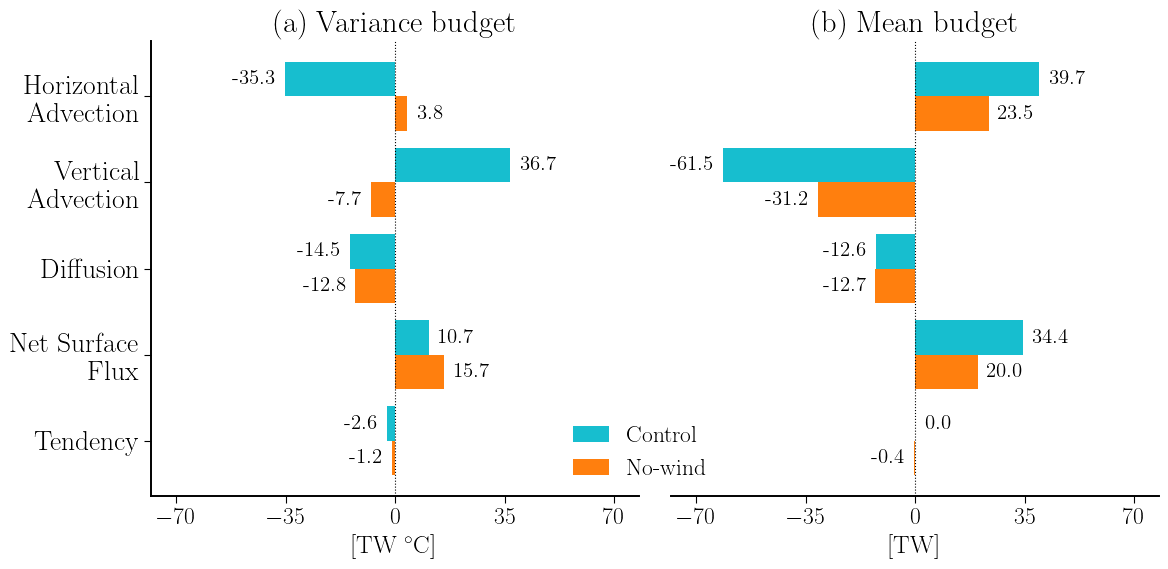

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

paired_diverging_barh(
    axes[0], display_labels, var_cntl, var_nowind,
    xlabel=r"[TW $^\circ$C]", title="(a) Variance budget",
    xlim=(-78, 78)
)
paired_diverging_barh(
    axes[1], display_labels, mean_cntl, mean_nowind,
    xlabel="[TW]", title="(b) Mean budget",
    xlim=(-78, 78)
)

axes[0].tick_params(axis='both', size=5)
axes[1].tick_params(axis='x', size=5)
axes[1].spines["left"].set_visible(False)
axes[1].tick_params(left=False, labelleft=False)

for ax in axes:
    ax.set_xticks(np.linspace(-70, 70, 5))
    
handles, labels_leg = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_leg, bbox_to_anchor=(0.62, 0.3), ncol=1, frameon=False, fontsize=17, handlelength=1.5)#, fancybox=False, edgecolor='grey')

plt.tight_layout()

#plt.savefig("./figures/fig6.png", dpi=200, bbox_inches='tight', facecolor='white')

## Figure 7:

In [7]:
mld_IS = pd.read_csv('./data/mld_summary_IndonesianSeas_MITgcm-RYF_cntl.csv')

mld_mean_IS = mld_IS.loc[mld_IS['quantity'] == 'MLD_mean', 'value'].values[0]
mld_sd_IS   = mld_IS.loc[mld_IS['quantity'] == 'MLD_sd', 'value'].values[0]


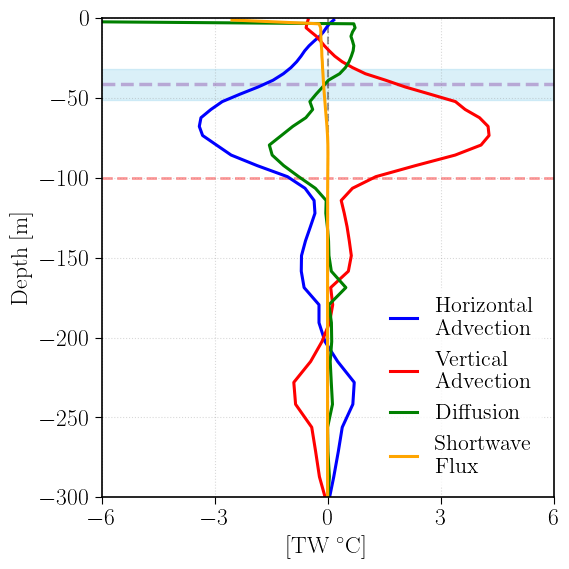

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
depth = ds_profile_cntl.Z.values
lw=2.2
ax.axvline(x=0, color='k', ls='--', alpha=0.4)
l0, = ax.plot(ds_profile_cntl.pfl_T_advh_anom.mean('time'), depth, color='blue',   lw=lw, label="Horizontal \n Advection")
l1, = ax.plot(ds_profile_cntl.pfl_T_advr_anom.mean('time'), depth, color='red',    lw=lw, label="Vertical \n Advection")
l2, = ax.plot(ds_profile_cntl.pfl_T_diff.mean('time'),      depth, color='green',  lw=lw, label="Diffusion")
l3, = ax.plot(ds_profile_cntl.pfl_T_qsw.mean('time'),       depth, color='orange', lw=lw, label="Shortwave \n Flux")

l4 = ax.axhline(-mld_mean_IS, color='purple', linestyle='--', lw=2.5, alpha=0.4, zorder=0)
l5 = ax.fill_between(
    x=[-10, 10],
    y1=-(mld_mean_IS + mld_sd_IS),
    y2=-(mld_mean_IS - mld_sd_IS),
    color='skyblue', alpha=0.3, zorder=0)
ax.axhline(y=-100, color='r', ls='--', lw=2, alpha=0.4, zorder=0)

ax.set_ylim([-300, 0])
ax.set_xlim(-6, 6)
ax.set_xticks(np.linspace(-6, 6, 5))
ax.set_title("")
ax.set_xlabel(r'[TW $^\circ$C]')
ax.set_ylabel("Depth [m]")
ax.grid(ls=":", color="grey", alpha=0.3)
ax.legend(frameon=True, fontsize=16, handlelength=1.2, loc="lower right", fancybox=False,edgecolor='None')
ax.tick_params(axis='both', size=5)
ax.spines[["top", "right", "bottom", "left"]].set_linewidth(1.2)

plt.tight_layout()

#plt.savefig("./figures/fig7.png", dpi=200, bbox_inches="tight", facecolor="white")

## Figure 8:

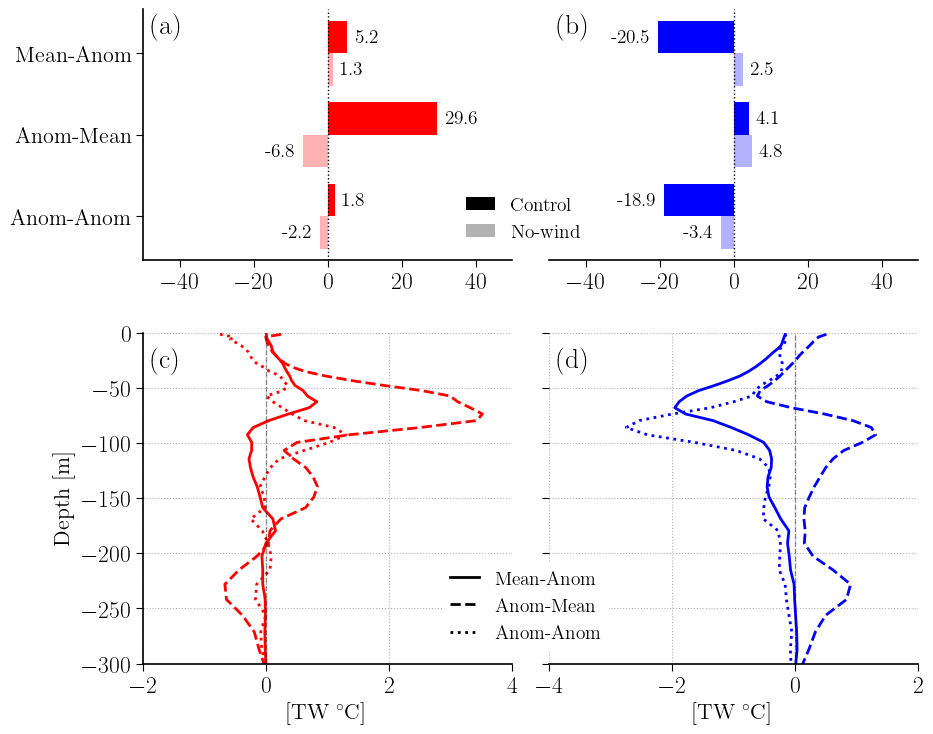

In [9]:
display_labels = ["Mean-Anom", "Anom-Mean", "Anom-Anom"]
h_vars = ["T_A1_H", "T_A2_H", "T_A3_H"]
r_vars = ["T_A1_R", "T_A2_R", "T_A3_R"]

def extract_list(ds, var_list, time_mean=True):
    vals = []
    for v in var_list:
        x = ds[v]
        if time_mean:
            x = x.mean("time")
        vals.append(float(x))
    return np.array(vals)

h_cntl   = extract_list(ds_var_cntl,   h_vars)
h_nowind = extract_list(ds_var_nowind, h_vars)
r_cntl   = extract_list(ds_var_cntl,   r_vars)
r_nowind = extract_list(ds_var_nowind, r_vars)

# Bar plot function
def paired_diverging_barh(
    ax, labels, ctrl, nowind,
    bar_color, xlabel, title,
    ctrl_alpha=1.0, nowind_alpha=0.3,
    xlim=(-78, 78), offset=0.2, bar_h=0.4,
    annotate=True, title_fs=20, ytick_fs=16, ann_fs=14
):
    y = np.arange(len(labels))

    b_cntl = ax.barh(y + offset, ctrl,   height=bar_h, color=bar_color, alpha=ctrl_alpha,  label="Control", edgecolor=None)
    b_now  = ax.barh(y - offset, nowind, height=bar_h, color=bar_color, alpha=nowind_alpha, label="No-wind", edgecolor=None)

    ax.axvline(0, color="k", lw=1, ls=":")
    ax.set_xlim(xlim)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=ytick_fs)
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=title_fs, loc='left', y=0.87, x=0.02)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis='both', size=5)
    ax.spines[["top", "right", "bottom", "left"]].set_linewidth(1.2)
    if annotate:
        pad = 0.02 * (xlim[1] - xlim[0])
        for bars in (b_cntl, b_now):
            for bar in bars:
                w = bar.get_width()
                ax.text(
                    w + (pad if w >= 0 else -pad),
                    bar.get_y() + bar.get_height() / 2,
                    f"{w:.1f}",
                    va="center",
                    ha="left" if w >= 0 else "right",
                    fontsize=ann_fs
                )

    return b_cntl, b_now


fig = plt.figure(figsize=(10, 8.5))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.25, wspace=0.1,
                        height_ratios=[0.95, 1.25])

ax00 = fig.add_subplot(gs[0, 0])
ax01 = fig.add_subplot(gs[0, 1], sharey=ax00)
ax10 = fig.add_subplot(gs[1, 0])
ax11 = fig.add_subplot(gs[1, 1], sharey=ax10)

# Row 1: integrated bar plots
paired_diverging_barh(
    ax00, display_labels[::-1], r_cntl[::-1], r_nowind[::-1],
    bar_color='red',
    xlabel=r"", title="(a)",
    xlim=(-50, 50)
)
paired_diverging_barh(
    ax01, display_labels[::-1], h_cntl[::-1], h_nowind[::-1],
    bar_color='blue',
    xlabel=r"", title="(b)",
    xlim=(-50, 50)
)

ax01.spines["left"].set_visible(False)
ax01.tick_params(left=False, labelleft=False)

for ax in [ax00, ax01]:
    ax.set_xticks(np.linspace(-40, 40, 5))

# Row 1 legend
handles_r1, labels_r1 = ax00.get_legend_handles_labels()
proxy_handles_r1 = [
    mpatches.Patch(color='k', alpha=h[0].get_alpha())
    for h in handles_r1
]
for p in proxy_handles_r1:
    p.set_edgecolor('None')

fig.legend(proxy_handles_r1, labels_r1,
           bbox_to_anchor=(0.58, 0.68), ncol=1,
           frameon=False, fontsize=14, handlelength=1.5)

# Row 2: depth profiles (cntl)
Z = ds_profile_cntl.Z

# Left: vertical advection (red)
ax10.plot(ds_profile_cntl.pfl_T_a1_r.mean("time"), Z, color="r", ls="-",  lw=2, label=display_labels[0])
ax10.plot(ds_profile_cntl.pfl_T_a2_r.mean("time"), Z, color="r", ls="--", lw=2, label=display_labels[1])
ax10.plot(ds_profile_cntl.pfl_T_a3_r.mean("time"), Z, color="r", ls=":",  lw=2, label=display_labels[2])
ax10.set_title("(c)",   loc="left", fontsize=20, y=0.87, x=0.02)
ax10.set_xlabel(r"[TW $^\circ$C]", fontsize=16)
ax10.set_ylabel("Depth [m]",      fontsize=16)
ax10.set_ylim(-300, 0)
ax10.axvline(0, color="k", ls="--", alpha=0.4, lw=1)
ax10.set_xlim(-2, 4)
ax10.set_xticks([-2, 0, 2, 4])
ax10.grid(ls=":")
ax10.tick_params(axis="both", size=5)
ax10.spines[["top", "right", "bottom", "left"]].set_linewidth(1.2)
ax10.spines[["right","top"]].set_visible(False)

# Right: horizontal advection (blue)
ax11.plot(ds_profile_cntl.pfl_T_a1_h.mean("time"), Z, color="b", ls="-",  lw=2, label=display_labels[0])
ax11.plot(ds_profile_cntl.pfl_T_a2_h.mean("time"), Z, color="b", ls="--", lw=2, label=display_labels[1])
ax11.plot(ds_profile_cntl.pfl_T_a3_h.mean("time"), Z, color="b", ls=":",  lw=2, label=display_labels[2])
ax11.set_title("(d)", loc="left", fontsize=20, y=0.87, x=0.02)
ax11.set_xlabel(r"[TW $^\circ$C]", fontsize=16)
ax11.set_ylim(-300, 0)
ax11.axvline(0, color="k", ls="--", alpha=0.4, lw=1)
ax11.set_xlim(-4, 2)
ax11.set_xticks([-4, -2, 0, 2])
ax11.grid(ls=":")
ax11.tick_params(axis="both", size=5,)
ax11.tick_params(labelleft=False)
ax11.spines[["top", "left", "right"]].set_visible(False)
ax11.spines[["top", "bottom", "left", "right"]].set_linewidth(1.2)

# Row 2 legend
handles_r2, labels_r2 = ax10.get_legend_handles_labels()
proxy_handles = [Line2D([0], [0], color="k", lw=2, ls=h.get_linestyle()) for h in handles_r2]
leg = fig.legend(proxy_handles, labels_r2,
           bbox_to_anchor=(0.6, 0.24), ncol=1,
           frameon=True, fancybox=False, fontsize=14, handlelength=1.5, edgecolor='None', facecolor='white')
leg.get_frame().set_alpha(1.0)

#plt.savefig("./figures/fig8.png", dpi=200, bbox_inches='tight', facecolor='white')